In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import os
import torch.amp as amp

# --- 1. SETTINGS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/kaggle/input/sugarcane-new-dataset/Sugarcane_Combined_Dataset/Train"

# --- 2. EXTRACT LABELS FROM FILENAMES ---
def get_variety_from_filename(filename):
    """
    Extracts the variety code. 
    Handles: 'aug_0_CPF-251.png' -> 'CPF-251' 
    Handles: 'orig_CP77-400.png' -> 'CP77-400'
    """
    # Remove extension
    name = os.path.splitext(filename)[0]
    # Split by underscores and take the last part (or logic based on your specific naming)
    parts = name.split('_')
    # The variety name is usually the last part or contains the hyphen
    variety = parts[-1].split(' ')[0] # Handles cases like '(2).png'
    return variety

files = [f for f in os.listdir(data_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
varieties = [get_variety_from_filename(f) for f in files]

# Encode text labels to numbers
le = LabelEncoder()
encoded_labels = le.fit_transform(varieties)
class_names = le.classes_

print(f"✅ Found {len(files)} images.")
print(f"🌿 Detected {len(class_names)} Varieties: {class_names}")

# --- 3. CUSTOM DATASET CLASS ---
class SugarcaneFilenameDataset(Dataset):
    def __init__(self, file_list, labels, root_dir, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self): return len(self.file_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.file_list[idx])
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform: image = self.transform(image)
        return image, label

# --- 4. PREPARE DATA LOADERS ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = SugarcaneFilenameDataset(files, encoded_labels, data_dir, transform)

# Split 80/20
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# --- 5. MODEL, OPTIMIZER, & TRAINING ---
model = resnet50(weights=ResNet50_Weights.DEFAULT)
# Fine-tune: freeze early layers, unfreeze layer4
for param in model.parameters(): param.requires_grad = False
for param in model.layer4.parameters(): param.requires_grad = True

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, len(class_names))
)
model = model.to(device)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()
scaler = amp.GradScaler('cuda')

print("🟢 Starting Training...")
for epoch in range(15):
    model.train()
    total_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        with amp.autocast('cuda'):
            loss = criterion(model(imgs), lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    
    # Quick Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, pred = torch.max(model(imgs), 1)
            total += lbls.size(0)
            correct += (pred == lbls).sum().item()
    
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {100*correct/total:.2f}%")

torch.save(model.state_dict(), 'sugarcane_model.pth')
print("⭐ Training Finished and Model Saved!")

✅ Found 400 images.
🌿 Detected 17 Varieties: ['CP77-400' 'CPF-237' 'CPF-246' 'CPF-247' 'CPF-248' 'CPF-249' 'CPF-250'
 'CPF-251' 'CPF-252' 'CPF-253' 'CoJ-84' 'HSF-240' 'NSG-59' 'SPF-213'
 'SPF-234' 'SPF-93' 'YTFG-236']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s] 


🟢 Starting Training...
Epoch 01 | Loss: 2.8055 | Val Acc: 30.00%
Epoch 02 | Loss: 2.6804 | Val Acc: 53.75%
Epoch 03 | Loss: 2.4391 | Val Acc: 67.50%
Epoch 04 | Loss: 2.0230 | Val Acc: 78.75%
Epoch 05 | Loss: 1.5452 | Val Acc: 83.75%
Epoch 06 | Loss: 1.0729 | Val Acc: 91.25%
Epoch 07 | Loss: 0.6239 | Val Acc: 92.50%
Epoch 08 | Loss: 0.3636 | Val Acc: 92.50%
Epoch 09 | Loss: 0.2246 | Val Acc: 96.25%
Epoch 10 | Loss: 0.1429 | Val Acc: 96.25%
Epoch 11 | Loss: 0.0809 | Val Acc: 98.75%
Epoch 12 | Loss: 0.0430 | Val Acc: 98.75%
Epoch 13 | Loss: 0.0298 | Val Acc: 96.25%
Epoch 14 | Loss: 0.0316 | Val Acc: 98.75%
Epoch 15 | Loss: 0.0245 | Val Acc: 96.25%
⭐ Training Finished and Model Saved!


In [2]:
import pandas as pd

def evaluate_all_images(model, dataset, le):
    model.eval()
    results = []
    
    print(f"🧐 Evaluating {len(dataset)} images...")
    
    with torch.no_grad():
        # Iterate through the entire validation dataset
        for idx in range(len(dataset)):
            image, label = dataset[idx]
            filename = dataset.dataset.file_list[dataset.indices[idx]] # Get original filename
            
            # Model prediction
            input_tensor = image.unsqueeze(0).to(device)
            outputs = model(input_tensor)
            _, pred = torch.max(outputs, 1)
            
            # Map back to names
            actual_name = le.inverse_transform([label])[0]
            predicted_name = le.inverse_transform([pred.item()])[0]
            
            # Determine status
            is_correct = "✅ DETECTED" if actual_name == predicted_name else "❌ MISSED"
            
            results.append({
                "Filename": filename,
                "Actual": actual_name,
                "Predicted": predicted_name,
                "Status": is_correct
            })

    # Create a clean table/dataframe of results
    results_df = pd.DataFrame(results)
    
    # Print the summary
    print("\n--- DETECTION SUMMARY ---")
    print(results_df.to_string(index=False)) # Use to_string to show all rows if short
    
    # Final Stats
    correct_count = (results_df['Status'] == "✅ DETECTED").sum()
    print(f"\n⭐ TOTAL ACCURACY: {100 * correct_count / len(dataset):.2f}%")
    
    return results_df

# Run the full evaluation
detailed_results = evaluate_all_images(model, val_dataset, le)

🧐 Evaluating 80 images...

--- DETECTION SUMMARY ---
                     Filename   Actual Predicted     Status
            aug_1_CPF-253.png  CPF-253   CPF-253 ✅ DETECTED
      aug_0_aug_1_CPF-247.png  CPF-247   CPF-247 ✅ DETECTED
           aug_1_CP77-400.png CP77-400  CP77-400 ✅ DETECTED
         orig_CPF-253 (2).png  CPF-253   CPF-253 ✅ DETECTED
        aug_1_CPF-246 (2).png  CPF-246   CPF-246 ✅ DETECTED
      orig_aug_0_YTFG-236.png YTFG-236  YTFG-236 ✅ DETECTED
 aug_0_aug_0_CPF-237 (2).jpeg  CPF-237   CPF-237 ✅ DETECTED
   aug_1_aug_1_SPF-93 (2).png   SPF-93    SPF-93 ✅ DETECTED
 aug_3_aug_0_SPF-234 (2).jpeg  SPF-234   SPF-234 ✅ DETECTED
        orig_YTFG-236 (2).png YTFG-236  YTFG-236 ✅ DETECTED
       orig_aug_0_CPF-249.png  CPF-249   CPF-249 ✅ DETECTED
   aug_0_aug_0_NSG-59 (2).png   NSG-59    NSG-59 ✅ DETECTED
 aug_0_aug_1_SPF-234 (2).jpeg  SPF-234   SPF-234 ✅ DETECTED
       orig_CP77-400 (2).jpeg CP77-400  CP77-400 ✅ DETECTED
        aug_2_CPF-253 (2).png  CPF-253   CPF-25

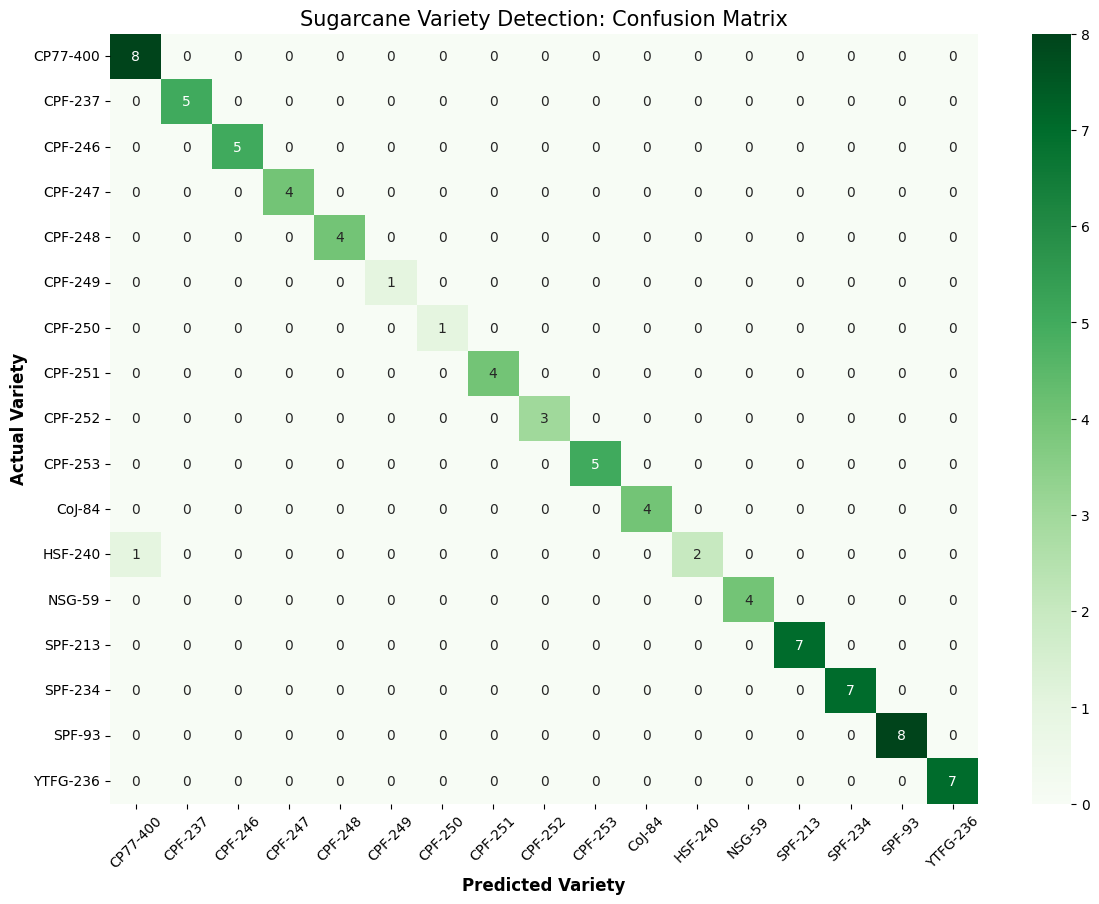


DETAILED PERFORMANCE REPORT
              precision    recall  f1-score   support

    CP77-400       0.89      1.00      0.94         8
     CPF-237       1.00      1.00      1.00         5
     CPF-246       1.00      1.00      1.00         5
     CPF-247       1.00      1.00      1.00         4
     CPF-248       1.00      1.00      1.00         4
     CPF-249       1.00      1.00      1.00         1
     CPF-250       1.00      1.00      1.00         1
     CPF-251       1.00      1.00      1.00         4
     CPF-252       1.00      1.00      1.00         3
     CPF-253       1.00      1.00      1.00         5
      CoJ-84       1.00      1.00      1.00         4
     HSF-240       1.00      0.67      0.80         3
      NSG-59       1.00      1.00      1.00         4
     SPF-213       1.00      1.00      1.00         7
     SPF-234       1.00      1.00      1.00         7
      SPF-93       1.00      1.00      1.00         8
    YTFG-236       1.00      1.00      1.00         

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(results_df, class_names):
    y_true = results_df['Actual']
    y_pred = results_df['Predicted']
    
    # 1. Create the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    # 2. Plotting
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    
    plt.xlabel('Predicted Variety', fontsize=12, fontweight='bold')
    plt.ylabel('Actual Variety', fontsize=12, fontweight='bold')
    plt.title('Sugarcane Variety Detection: Confusion Matrix', fontsize=15)
    plt.xticks(rotation=45)
    plt.show()
    
    # 3. Text Report (Precision, Recall, F1-Score)
    print("\n" + "="*30)
    print("DETAILED PERFORMANCE REPORT")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=class_names))

# Run the visualization
plot_confusion_matrix(detailed_results, class_names)

📋 --- DATASET SPLIT SUMMARY ---
Total Images: 400
Training set: 320 images (Used to teach the AI)
Testing set:  80 images (Used to verify accuracy)
----------------------------------------

🌿 --- IMAGES PER VARIETY DETAIL ---
 Variety  Train_Count  Test_Count  Total
CP77-400           18           8     26
 CPF-237           21           5     26
 CPF-246           21           5     26
 CPF-247           18           4     22
 CPF-248           22           4     26
 CPF-249           10           1     11
 CPF-250           10           1     11
 CPF-251           22           4     26
 CPF-252           19           3     22
 CPF-253           21           5     26
  CoJ-84           22           4     26
 HSF-240           23           3     26
  NSG-59           22           4     26
 SPF-213           19           7     26
 SPF-234           15           7     22
  SPF-93           18           8     26
YTFG-236           19           7     26


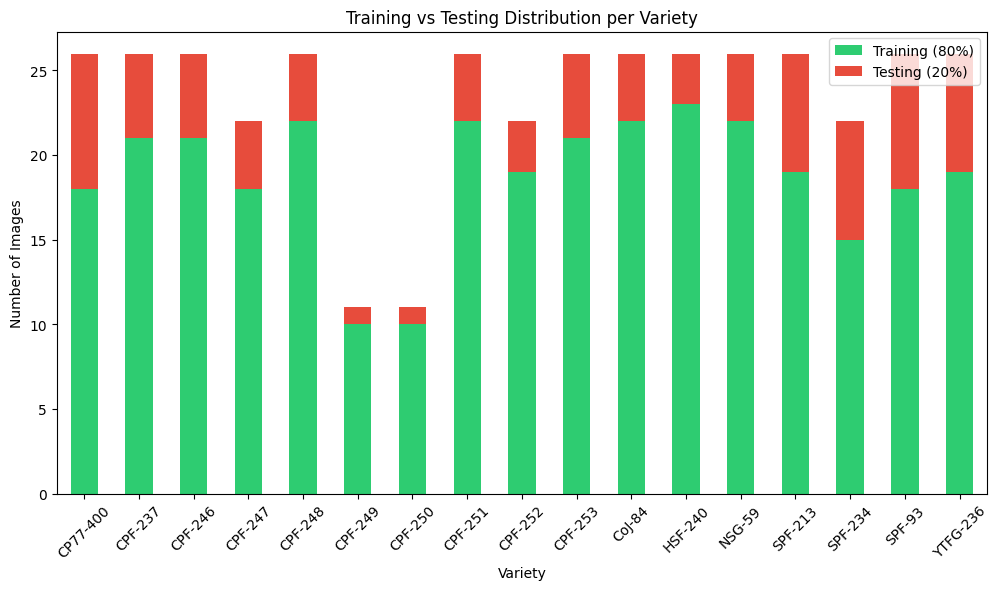

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def get_complete_dataset_report(train_ds, val_ds, le):
    # 1. Get counts for Train and Val
    train_count = len(train_ds)
    val_count = len(val_ds)
    total_count = train_count + val_count
    
    # 2. Extract Labels to see variety distribution in Training
    train_labels = [train_ds[i][1] for i in range(len(train_ds))]
    train_variety_names = le.inverse_transform(train_labels)
    train_df_stats = pd.Series(train_variety_names).value_counts().reset_index()
    train_df_stats.columns = ['Variety', 'Train_Count']
    
    # 3. Extract Labels for Validation (Testing)
    val_labels = [val_ds[i][1] for i in range(len(val_ds))]
    val_variety_names = le.inverse_transform(val_labels)
    val_df_stats = pd.Series(val_variety_names).value_counts().reset_index()
    val_df_stats.columns = ['Variety', 'Test_Count']
    
    # 4. Merge into one master table
    report = pd.merge(train_df_stats, val_df_stats, on='Variety', how='outer').fillna(0)
    report['Total'] = report['Train_Count'] + report['Test_Count']
    
    # --- PRINT SUMMARY ---
    print("📋 --- DATASET SPLIT SUMMARY ---")
    print(f"Total Images: {total_count}")
    print(f"Training set: {train_count} images (Used to teach the AI)")
    print(f"Testing set:  {val_count} images (Used to verify accuracy)")
    print("-" * 40)
    
    print("\n🌿 --- IMAGES PER VARIETY DETAIL ---")
    print(report.to_string(index=False))
    
    # --- VISUALIZE ---
    report.set_index('Variety')[['Train_Count', 'Test_Count']].plot(kind='bar', stacked=True, figsize=(12,6), color=['#2ecc71', '#e74c3c'])
    plt.title('Training vs Testing Distribution per Variety')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45)
    plt.legend(["Training (80%)", "Testing (20%)"])
    plt.show()

# Run the report
get_complete_dataset_report(train_dataset, val_dataset, le)

In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split

# 1. Setup paths
source_dir = "/kaggle/input/sugarcane-new-dataset/Sugarcane_Combined_Dataset/Train"
output_dir = "/kaggle/working/sugarcane_split"

# 2. Get all image files and their labels
all_files = [f for f in os.listdir(source_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
# Extract variety (label) from filename like the notebook does
labels = [f.split('_')[-1].split('.')[0] for f in all_files]

# 3. Perform the Split (80% Train, 10% Val, 10% Test)
# First: Split off the 320 training images (80%)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files, labels, test_size=0.20, random_state=42, stratify=labels
)

# Second: Split the remaining 80 images into 40 Val and 40 Test (50/50 of the remainder)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

# 4. Function to create folders and copy files
def move_files(files, subset_name):
    for f in files:
        label = f.split('_')[-1].split('.')[0] # Get variety name
        target_folder = os.path.join(output_dir, subset_name, label)
        os.makedirs(target_folder, exist_ok=True)
        shutil.copy(os.path.join(source_dir, f), os.path.join(target_folder, f))

# 5. Execute copying
move_files(train_files, 'train')
move_files(val_files, 'val')
move_files(test_files, 'test')

print(f"✅ Folders created at: {output_dir}")
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

✅ Folders created at: /kaggle/working/sugarcane_split
Train: 320 | Val: 40 | Test: 40


In [6]:
import shutil
import os

# Zip the folder you created earlier
shutil.make_archive('sugarcane_data', 'zip', '/kaggle/working/sugarcane_split')

print("✅ ZIP file created! You can now download 'sugarcane_data.zip' from the right panel.")

✅ ZIP file created! You can now download 'sugarcane_data.zip' from the right panel.
